# Plot Convective Cell Density for MRMS Data (2021-2024)

✅ Saved: Plot_Combined_3HR_Spatial_Hist_PIXEL\combined_3hr_spatial_top_hist_bottom.png


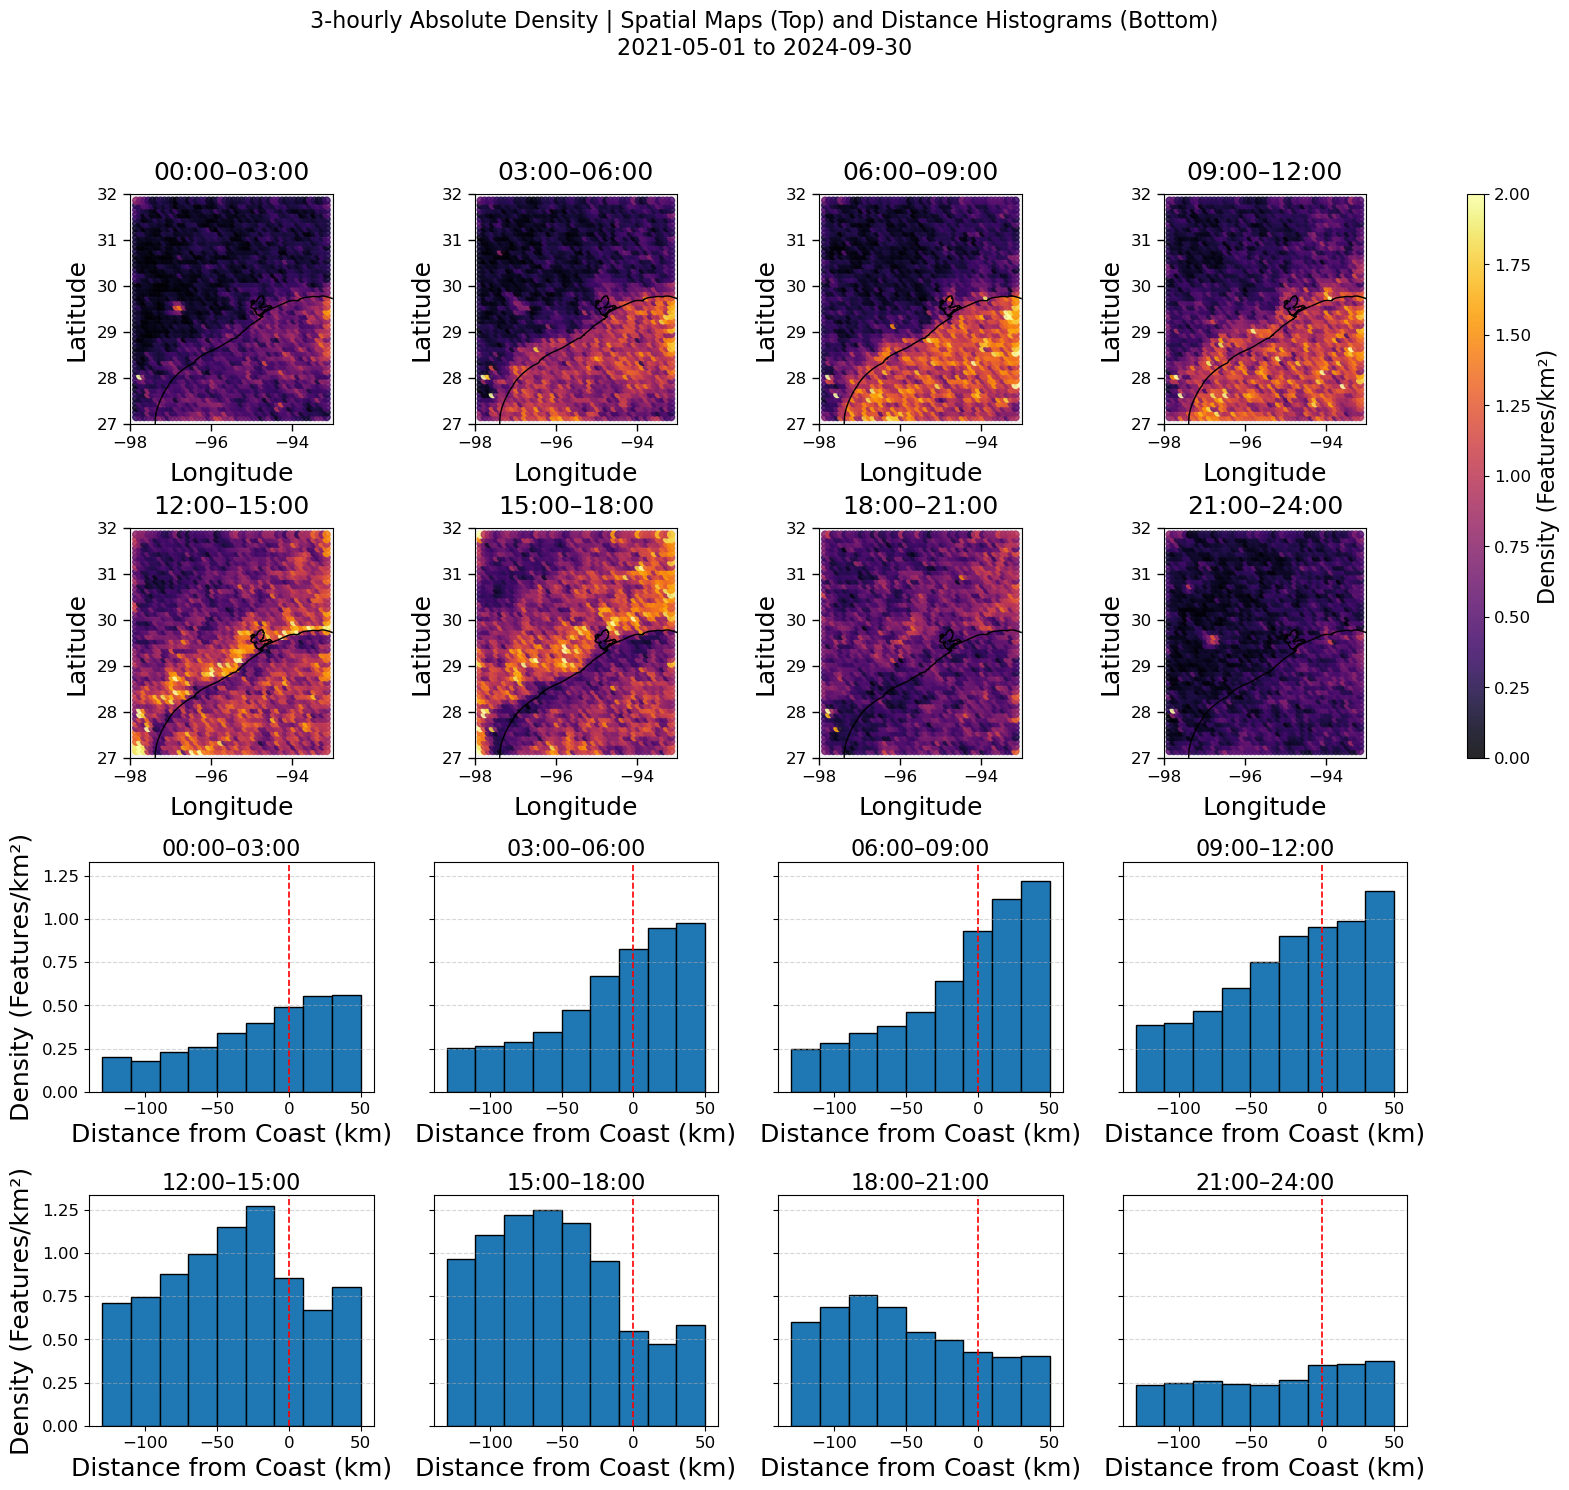

In [4]:
# -*- coding: utf-8 -*-
import iris
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.ops import nearest_points
from geopy.distance import geodesic
from pathlib import Path
import matplotlib.pyplot as plt
import glob

# =========================
# Plot style
# =========================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 16,
    "figure.titlesize": 16
})

# =========================
# Settings
# =========================
YEAR_START = "2021-05-01"
YEAR_END   = "2024-09-30"

lon_min, lon_max = -98, -93
lat_min, lat_max = 27, 32

# Grid setup
ddeg = 0.1
half_cell = 0.05
cell_area_km2 = 0.05 * 0.05 * 111 * 111  # keep same as your original script

# Distance bins (km)
bin_edges = np.arange(-130, 60, 20)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

# 3-hour periods
three_hour_periods = [(h, h + 3) for h in range(0, 24, 3)]

# Scatter color scale
VMIN, VMAX = 0, 2

# Output
plot_dir = Path("Plot_Combined_3HR_Spatial_Hist_PIXEL")
plot_dir.mkdir(exist_ok=True)
out_png = plot_dir / "combined_3hr_spatial_top_hist_bottom.png"

# =========================
# Load Land-Sea Mask + Coastline
# =========================
def load_land_sea_mask(mask_file):
    return iris.load_cube(mask_file)

def calculate_distance_with_mask(point, coastline, land_sea_mask):
    nearest_geom = coastline.geometry.unary_union
    nearest_point_on_coastline = nearest_points(point, nearest_geom)[1]
    distance_km = geodesic(
        (point.y, point.x),
        (nearest_point_on_coastline.y, nearest_point_on_coastline.x)
    ).km

    lat, lon = point.y, point.x
    mask_lon = land_sea_mask.coord("longitude").points
    mask_lat = land_sea_mask.coord("latitude").points

    lat_idx = np.abs(mask_lat - lat).argmin()
    lon_idx = np.abs(mask_lon - lon).argmin()
    mask_value = land_sea_mask.data[lat_idx, lon_idx]

    is_on_land = mask_value < 50
    return -distance_km if is_on_land else distance_km

land_sea_mask_file = "IMERG_land_sea_mask_regrid_SCREAM_5km.nc"
land_sea_mask = load_land_sea_mask(land_sea_mask_file)
coastline = gpd.read_file("clipped_us_coastline.shp")

# =========================
# Load initiation point CSVs
# =========================
csv_files = glob.glob("all_initiation_points_*.csv")
df_list = []
for file in csv_files:
    df = pd.read_csv(file)
    df["geometry"] = df.apply(lambda r: Point(r["longitude"], r["latitude"]), axis=1)
    df = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
    df["time"] = pd.to_datetime(df["time"])
    df_list.append(df)

gdf_clusters = pd.concat(df_list, ignore_index=True)
gdf_clusters = gdf_clusters[
    (gdf_clusters["time"] >= YEAR_START) & (gdf_clusters["time"] <= YEAR_END)
].copy()

# Clip to domain
domain_poly = box(lon_min, lat_min, lon_max, lat_max)
gdf_clusters = gdf_clusters[gdf_clusters.geometry.within(domain_poly)].copy()

# =========================
# Build grid centers for scatter
# =========================
grid_lons = np.arange(lon_min, lon_max, ddeg)
grid_lats = np.arange(lat_min, lat_max, ddeg)

# use true cell centers
grid_centers = [Point(lon + ddeg/2, lat + ddeg/2) for lat in grid_lats for lon in grid_lons]

gdf_grid_scatter = gpd.GeoDataFrame({"geometry": grid_centers}, crs="EPSG:4326")
gdf_grid_scatter = gdf_grid_scatter[gdf_grid_scatter.geometry.within(domain_poly)].copy()

# =========================
# Build grid centers + cell polygons for histogram
# =========================
centers = [Point(lon + ddeg/2, lat + ddeg/2) for lat in grid_lats for lon in grid_lons]
gdf_grid_hist = gpd.GeoDataFrame({"geometry": centers}, geometry="geometry", crs="EPSG:4326")
gdf_grid_hist = gdf_grid_hist[gdf_grid_hist.geometry.within(domain_poly)].copy()

gdf_grid_hist["cell"] = gdf_grid_hist.geometry.apply(lambda p: p.buffer(half_cell).envelope)

grid_cells = gpd.GeoDataFrame(
    {"cell_id": np.arange(len(gdf_grid_hist))},
    geometry=gdf_grid_hist["cell"],
    crs="EPSG:4326"
)

gdf_grid_hist["distance_to_coast"] = gdf_grid_hist["geometry"].apply(
    lambda pt: calculate_distance_with_mask(pt, coastline, land_sea_mask)
)

# =========================
# Helper: gridwise density for histogram row
# =========================
def grid_density_for_period(start_hour, end_hour):
    period_pts = gdf_clusters[
        (gdf_clusters["time"].dt.hour >= start_hour) &
        (gdf_clusters["time"].dt.hour < end_hour)
    ][["geometry"]].copy()

    density_1d = np.zeros(len(gdf_grid_hist), dtype=float)

    if not period_pts.empty:
        joined = gpd.sjoin(period_pts, grid_cells, how="left", predicate="within")
        counts = joined.groupby("cell_id").size()
        density_1d[counts.index.values] = counts.values / cell_area_km2

    return density_1d

# =========================
# Precompute histogram values for common y-axis
# =========================
all_hist_values = []

for (start_hour, end_hour) in three_hour_periods:
    gdf_grid_hist["absolute_density"] = grid_density_for_period(start_hour, end_hour)

    hist_values = []
    for j in range(len(bin_edges) - 1):
        m = (
            (gdf_grid_hist["distance_to_coast"] >= bin_edges[j]) &
            (gdf_grid_hist["distance_to_coast"] < bin_edges[j + 1])
        )
        hist_values.append(gdf_grid_hist.loc[m, "absolute_density"].mean())

    all_hist_values.append(hist_values)

global_max = np.nanmax(np.array(all_hist_values))
common_ylim = (0, global_max * 1.05)

# =========================
# Combined figure
# =========================
fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(
    nrows=4, ncols=5,
    width_ratios=[1, 1, 1, 1, 0.06],
    height_ratios=[1, 1, 1, 1],
    wspace=0.26,
    hspace=0.45
)

# Top: spatial scatter
axes_top = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
    fig.add_subplot(gs[1, 3]),
]
cax_top = fig.add_subplot(gs[0:2, 4])

# Bottom: histograms with shared y inside each row
ax20 = fig.add_subplot(gs[2, 0])
ax21 = fig.add_subplot(gs[2, 1], sharey=ax20)
ax22 = fig.add_subplot(gs[2, 2], sharey=ax20)
ax23 = fig.add_subplot(gs[2, 3], sharey=ax20)

ax30 = fig.add_subplot(gs[3, 0], sharey=ax20)
ax31 = fig.add_subplot(gs[3, 1], sharey=ax20)
ax32 = fig.add_subplot(gs[3, 2], sharey=ax20)
ax33 = fig.add_subplot(gs[3, 3], sharey=ax20)

axes_bot = [ax20, ax21, ax22, ax23, ax30, ax31, ax32, ax33]
cax_bot = fig.add_subplot(gs[2:4, 4])

last_sc = None

for i, (start_hour, end_hour) in enumerate(three_hour_periods):
    # -------------------------
    # TOP: spatial scatter
    # -------------------------
    ax_top = axes_top[i]
    ax_top.set_facecolor("0.95")

    period_data = gdf_clusters[
        (gdf_clusters["time"].dt.hour >= start_hour) &
        (gdf_clusters["time"].dt.hour < end_hour)
    ].copy()

    absolute_densities_scatter = []
    for grid_center in gdf_grid_scatter["geometry"]:
        grid_box = grid_center.buffer(half_cell).envelope
        count = period_data[period_data["geometry"].within(grid_box)].shape[0]
        absolute_densities_scatter.append(count / cell_area_km2)

    gdf_grid_scatter["absolute_density"] = absolute_densities_scatter

    # reshape to 2D grid
    nlat = len(grid_lats)
    nlon = len(grid_lons)
    density_2d = np.full((nlat, nlon), np.nan)

    for idx, pt in enumerate(gdf_grid_scatter.geometry):
        lon_idx = int(round((pt.x - (lon_min + ddeg/2)) / ddeg))
        lat_idx = int(round((pt.y - (lat_min + ddeg/2)) / ddeg))

        if 0 <= lon_idx < nlon and 0 <= lat_idx < nlat:
            density_2d[lat_idx, lon_idx] = gdf_grid_scatter.iloc[idx]["absolute_density"]

    # -------------------------
    # Remove the outer border pixels completely
    # -------------------------
    density_2d_clean = density_2d.copy()
    density_2d_clean[0, :] = np.nan
    density_2d_clean[-1, :] = np.nan
    density_2d_clean[:, 0] = np.nan
    density_2d_clean[:, -1] = np.nan

    # flatten back to plotting vector
    cleaned_values = []
    for pt in gdf_grid_scatter.geometry:
        lon_idx = int(round((pt.x - (lon_min + ddeg/2)) / ddeg))
        lat_idx = int(round((pt.y - (lat_min + ddeg/2)) / ddeg))

        if 0 <= lon_idx < nlon and 0 <= lat_idx < nlat:
            cleaned_values.append(density_2d_clean[lat_idx, lon_idx])
        else:
            cleaned_values.append(np.nan)

    gdf_grid_scatter["absolute_density_clean"] = cleaned_values

    coastline.plot(ax=ax_top, color="black", linewidth=1.0)

    sc = ax_top.scatter(
        gdf_grid_scatter.geometry.x, gdf_grid_scatter.geometry.y,
        c=gdf_grid_scatter["absolute_density_clean"],
        cmap="inferno", s=25, alpha=0.85,
        vmin=VMIN, vmax=VMAX
    )
    last_sc = sc

    ax_top.set_xlim(lon_min, lon_max)
    ax_top.set_ylim(lat_min, lat_max)
    ax_top.set_title(f"{start_hour:02d}:00–{end_hour:02d}:00", pad=10)
    ax_top.set_xlabel("Longitude", labelpad=8)
    ax_top.set_ylabel("Latitude", labelpad=6)
    ax_top.tick_params(axis="both", which="major", length=5, width=1)

    # -------------------------
    # BOTTOM: histogram
    # -------------------------
    ax_bot = axes_bot[i]
    hist_values = all_hist_values[i]

    ax_bot.bar(bin_centers, hist_values, width=bin_width, edgecolor="black")
    ax_bot.axvline(0, color="red", linestyle="--", linewidth=1.2)

    ax_bot.set_title(f"{start_hour:02d}:00–{end_hour:02d}:00", fontsize=16, pad=4)
    ax_bot.set_xlabel("Distance from Coast (km)")
    ax_bot.grid(axis="y", linestyle="--", alpha=0.5)
    ax_bot.set_ylim(*common_ylim)

    if i in [0, 4]:
        ax_bot.set_ylabel("Density (Features/km²)", labelpad=6)
    else:
        ax_bot.set_ylabel("")
        ax_bot.tick_params(axis="y", labelleft=False)

# Top colorbar
cbar_top = fig.colorbar(last_sc, cax=cax_top)
cbar_top.set_label("Density (Features/km²)", fontsize=16)
cbar_top.ax.tick_params(labelsize=12)

# Bottom-right reserved axis not used
cax_bot.axis("off")

fig.suptitle(
    f"3-hourly Absolute Density | Spatial Maps (Top) and Distance Histograms (Bottom)\n{YEAR_START} to {YEAR_END}",
    y=0.995
)

plt.savefig(out_png, dpi=200, bbox_inches="tight")
print(f"✅ Saved: {out_png}")
#plt.close(fig)
plt.show()